### Zero-padding (Fourier resampling).

- CDGR Volume: 0.5 Hz to 200 Hz

- AVEAA PIP: 0.2 Hz to 100 Hz

- AVEAA PEEP: 0.2 Hz to 100 Hz

- AVEAA Volume: 0.2 Hz to 100 Hz

In [66]:
# Load data

import pandas as pd

# Define the file path (CDGR ventilator)
file_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/02-EVENTS/a-CDGR+AVEAA+SVU(58)_20240205/a-58_CDGR_39_1st/a-58_CDGR_39_1st_OSI/a-58_CDGR_39_1st_tw/a_58_CDGR_39_1st (1).csv"

# # Define the file path (AVEAA ventilator)
# file_path = "/nfs/turbo/med-kayvan-lab/Projects/PARDS/02-Data/02-EVENTS/a-CDGR+AVEAA+SVU(58)_20240205/a-58_AVEAA_4_1st/a-58_AVEAA_4_1st_OSI/a-58_AVEAA_4_1st_tw/a_58_AVEAA_4_1st (1).csv"

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Remove rows with at least one empty value across all columns
df = df.dropna()

# Convert 'Time' column to datetime format
df['Time'] = pd.to_datetime(df['Time'], format='%Y-%m-%d %H:%M:%S.%f')

In [67]:
# (CDGR ventilator) 1st minute from the 2nd tumbling window.
start_time = '2023-10-04 17:41:00'
end_time = '2023-10-04 17:42:00'

# # (AVEAA ventilator) 1st minute from the 2nd tumbling window.
# start_time = '2023-12-18 20:24:00'
# end_time = '2023-12-18 20:25:00'

# Subset the data based on the time range
subset_df = df[(df['Time'] >= start_time) & (df['Time'] <= end_time)]

# Display the subset DataFrame
print(subset_df.info())
# print(subset_df.head())
# print(subset_df.tail())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5859 entries, 59127 to 64985
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Relative Time (sec)  5859 non-null   float64       
 1   Time                 5859 non-null   datetime64[ns]
 2   CDGR - FiO₂          5859 non-null   int64         
 3   CDGR - Paw           5859 non-null   int64         
 4   CDGR - eVT           5859 non-null   float64       
 5   CDGR - Flow          5859 non-null   float64       
 6   CDGR - iPress Wave   5859 non-null   float64       
 7   GE - SpO2 1          5859 non-null   float64       
 8   OSI                  5859 non-null   float64       
 9   Tumbling_window      5859 non-null   int64         
dtypes: datetime64[ns](1), float64(6), int64(3)
memory usage: 503.5 KB
None


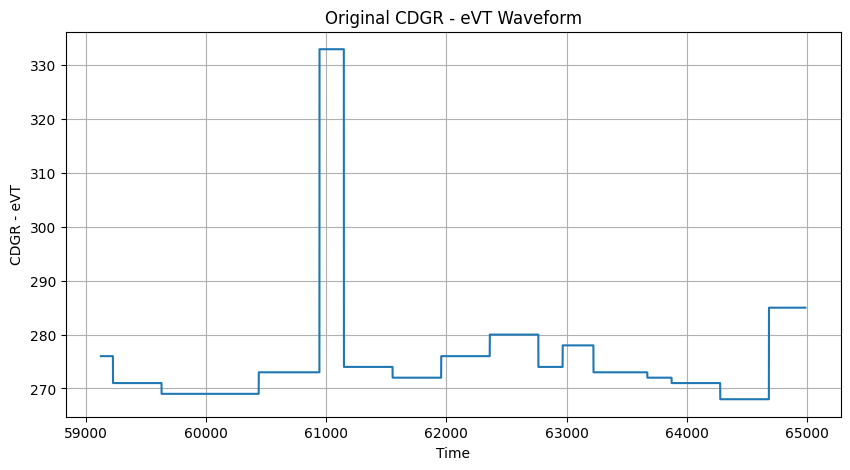

In [68]:
# CDGR volume time domain demo
import matplotlib.pyplot as plt

# Plot the original waveform
plt.figure(figsize=(10, 5))
plt.plot(subset_df['CDGR - eVT'])
plt.xlabel('Time')
plt.ylabel('CDGR - eVT')
plt.title('Original CDGR - eVT Waveform')
plt.grid(True)
plt.show()

# # AVEAA PIP time domain demo
# import matplotlib.pyplot as plt

# # Plot the original waveform
# plt.figure(figsize=(10, 5))
# plt.plot(subset_df['AVEA - PIP'])
# plt.xlabel('Time')
# plt.ylabel('AVEA - PIP')
# plt.title('Original AVEA - PIP')
# plt.grid(True)
# plt.show()

# # AVEAA PEEP time domain demo
# import matplotlib.pyplot as plt

# # Plot the original waveform
# plt.figure(figsize=(10, 5))
# plt.plot(subset_df['AVEA - PEEP'])
# plt.xlabel('Time')
# plt.ylabel('AVEA - PEEP')
# plt.title('Original AVEA - PEEP')
# plt.grid(True)
# plt.show()

# # AVEAA volume time domain demo
# import matplotlib.pyplot as plt

# # Plot the original waveform
# plt.figure(figsize=(10, 5))
# plt.plot(subset_df['AVEA - eVT'])
# plt.xlabel('Time')
# plt.ylabel('AVEA - eVT')
# plt.title('Original AVEA - eVT')
# plt.grid(True)
# plt.show()

In [69]:
# Zero-padding for CDGR Volume data (from 0.5 Hz to 200 Hz)

import numpy as np
from scipy.interpolate import interp1d

# Original sampling rate (0.5 Hz) and target sampling rate (200 Hz)
original_sampling_rate = 0.5  # Hz
target_sampling_rate = 200  # Hz

# Original time points
original_time_points = np.arange(0, len(subset_df['CDGR - eVT']) / original_sampling_rate, step=1/original_sampling_rate)

# Original data
original_data = subset_df['CDGR - eVT']

# Target time points (resampled at 200 Hz)
target_time_points = np.arange(0, original_time_points[-1], step=1/target_sampling_rate)

# Perform zero-padding (Fourier resampling)
interpolator = interp1d(original_time_points, original_data, kind='linear', fill_value='extrapolate')
resampled_data = interpolator(target_time_points)

# Print the resampled volume data and its shape
print("Resampled Volume Data:", resampled_data)
print("Resampled Volume Data Shape:", resampled_data.shape)

Resampled Volume Data: [276. 276. 276. ... 285. 285. 285.]
Resampled Volume Data Shape: (2343200,)


In [54]:
# # Zero-padding for AVEAA Volume data (from 0.2 Hz to 100 Hz)

# import numpy as np
# from scipy.interpolate import interp1d

# # Original sampling rate (0.2 Hz) and target sampling rate (100 Hz)
# original_sampling_rate = 0.2  # Hz
# target_sampling_rate = 100  # Hz

# # Original time points
# # original_time_points = np.arange(0, len(subset_df['AVEA - PIP']) / original_sampling_rate, step=1/original_sampling_rate)
# # original_time_points = np.arange(0, len(subset_df['AVEA - PEEP']) / original_sampling_rate, step=1/original_sampling_rate)
# original_time_points = np.arange(0, len(subset_df['AVEA - eVT']) / original_sampling_rate, step=1/original_sampling_rate)

# # Original data
# # original_data = subset_df['AVEA - PIP']
# # original_data = subset_df['AVEA - PEEP']
# original_data = subset_df['AVEA - eVT']

# # Target time points (resampled at 100 Hz)
# target_time_points = np.arange(0, original_time_points[-1], step=1/target_sampling_rate)

# # Perform zero-padding (Fourier resampling)
# interpolator = interp1d(original_time_points, original_data, kind='linear', fill_value='extrapolate')
# resampled_data = interpolator(target_time_points)

# # Print the resampled volume data and its shape
# print("Resampled Volume Data:", resampled_data)
# print("Resampled Volume Data Shape:", resampled_data.shape)

Resampled Volume Data: [20.008631   20.008631   20.008631   ... 71.59522989 71.56707993
 71.53892996]
Resampled Volume Data Shape: (3031000,)


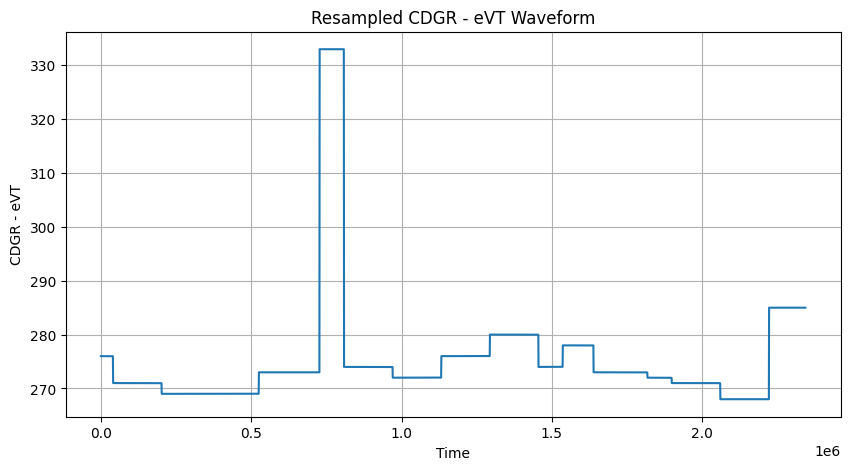

In [70]:
# CDGR volume time domain demo
import matplotlib.pyplot as plt

# Plot the Resampled waveform
plt.figure(figsize=(10, 5))
plt.plot(resampled_data)
plt.xlabel('Time')
plt.ylabel('CDGR - eVT')
plt.title('Resampled CDGR - eVT Waveform')
plt.grid(True)
plt.show()

# # AVEAA PIP time domain demo
# import matplotlib.pyplot as plt

# # Plot the Resampled waveform
# plt.figure(figsize=(10, 5))
# plt.plot(resampled_data)
# plt.xlabel('Time')
# plt.ylabel('AVEA - PIP')
# plt.title('Resampled AVEA - PIP')
# plt.grid(True)
# plt.show()

# # AVEAA PEEP time domain demo
# import matplotlib.pyplot as plt

# # Plot the Resampled waveform
# plt.figure(figsize=(10, 5))
# plt.plot(resampled_data)
# plt.xlabel('Time')
# plt.ylabel('AVEA - PEEP')
# plt.title('Resampled AVEA - PEEP')
# plt.grid(True)
# plt.show()

# # AVEAA volume time domain demo
# import matplotlib.pyplot as plt

# # Plot the Resampled waveform
# plt.figure(figsize=(10, 5))
# plt.plot(resampled_data)
# plt.xlabel('Time')
# plt.ylabel('AVEA - eVT')
# plt.title('Resampled AVEA - eVT')
# plt.grid(True)
# plt.show()

In [71]:
# Fourier transform

from scipy.fft import rfft, rfftfreq
from scipy.signal import find_peaks
import numpy as np

# Perform Fourier transform
x = resampled_data

fs = 200  # Sampling frequency (CDGR pressure and Flow)
# fs = 100  # Sampling frequency (AVEAA Flow)

# Number of samples in x
n = len(x)

# Compute the Fourier transform
yf = rfft(x)   # The amplitude
# yf = 20 * np.log10(yf)   # Convert amplitude to gain in decibels (dB)
xf = rfftfreq(n, 1 / fs)

In [74]:
# Apply Butterworth bandpass filter

from scipy.signal import butter, filtfilt

# Define the Butterworth filter parameters
fs = 200  # Sampling frequency
# fs = 100  # Sampling frequency
lowcut = 0.001  # Low cutoff frequency
highcut = 99.99  # High cutoff frequency
# highcut = 49  # High cutoff frequency
order = 3  # Filter order

# Design the Butterworth bandpass filter
nyquist = 0.5 * fs
low = lowcut / nyquist
high = highcut / nyquist
b, a = butter(order, [low, high], btype='band')

# Apply the Butterworth filter to the Fourier transformed data
filtered_yf = filtfilt(b, a, yf)

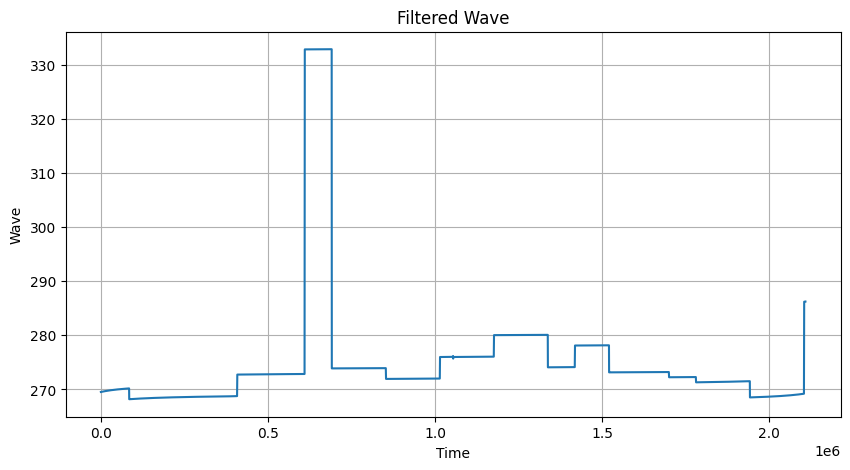

In [75]:
# Inverse Fourier transform

from scipy.fft import irfft
import matplotlib.pyplot as plt

# Perform inverse Fourier transform
inverted_signal = irfft(filtered_yf)

# Define the range of indices for the middle part of the plot
middle_start = int(len(inverted_signal) * 0.05)  # Start index of the middle part
middle_end = int(len(inverted_signal) * 0.95)    # End index of the middle part

# Plot both the real and imaginary parts of the inverted signal for the middle part
plt.figure(figsize=(10, 5))
plt.plot(inverted_signal[middle_start:middle_end])
plt.xlabel('Time')
plt.ylabel('Wave')
plt.title('Filtered Wave')
plt.grid(True)
plt.show()